# 1 - bibliotecas 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm


# 2 - paths 

In [2]:
label_path = "Sismica/train/Output/seismic_TRAIN_LABEL_crops.npy"
seismic_path = "Sismica/train/Input/seismic_TRAIN_IMAGE_crops.npy"
seismic_test = "Sismica/test/Input/seismic_TEST_IMAGE_crops_S.npy"

In [3]:
seismic = np.load(seismic_path)
label = np.load(label_path)
test = np.load(seismic_test)

In [4]:
seismic

array([[[ 314.90967 ,  237.88016 ,  161.49757 , ..., -502.72876 ,
         -521.31274 , -502.98462 ],
        [-255.15192 , -316.2876  , -383.25708 , ..., -294.50537 ,
         -379.58887 , -437.45654 ],
        [-576.45605 , -564.44434 , -556.95557 , ...,  141.2532  ,
           47.26915 ,  -46.431366],
        ...,
        [ 454.85132 ,  651.3489  ,  719.0576  , ...,  170.58904 ,
          316.43066 ,  364.12402 ],
        [ 604.2803  ,  790.7825  ,  909.55347 , ...,   19.218903,
           44.073532,   34.23491 ],
        [ 517.24243 ,  574.48145 ,  688.4656  , ...,  -99.948425,
         -180.76651 , -234.48941 ]],

       [[-121.20087 , -162.96156 , -207.82088 , ...,  210.46043 ,
          190.47864 ,  154.83926 ],
        [ -38.64006 ,  -93.16231 , -133.7568  , ..., -130.19002 ,
         -151.10216 , -217.035   ],
        [ 232.18768 ,  170.1328  ,  126.59544 , ..., -388.52344 ,
         -382.00977 , -420.73267 ],
        ...,
        [ -73.978455,  -16.672379,   -2.820404, ..., -

vendo se pode ser possivel analisar a frequencia

# normalizaçao min-max 

In [5]:

def minmax(vol):
    """
    Normalizes a NumPy array to the range [0, 1] using OpenCV's min-max scaling.
    
    Note: The 'eps' argument is part of your original signature but is not
    used by cv2.NORM_MINMAX, as OpenCV handles potential division by zero.
    """
    # The cv2.normalize function returns the normalized array
    normalized_array = cv2.normalize(
        vol,            # Source array
        None,           # Destination array (None means create a new one)
        alpha=0,        # The minimum value of the target range
        beta=1,         # The maximum value of the target range
        norm_type=cv2.NORM_MINMAX,  # The normalization type
        dtype=cv2.CV_32F  # The data type of the output array
    )
    return normalized_array

# nessa parte para normalizar o sismica ou o teste precisa alterar a variavel

In [7]:
# siesmic ou test -> escolha 

vol = test #               troque pela varaivael de teste para normalizar !!!
vol_n = minmax(vol)                 # (1) normalização               
volume_normalizado = vol_n

In [8]:
arr = volume_normalizado  # float32/float64

# Opcional: tratar NaN/Inf para evitar sujeira no min/max
arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)

# Normaliza min->0, max->255 no volume inteiro
scaled_to_255_arr = cv2.normalize(
    arr, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8U
)

print("\nScaled to 0-255 array (uint8):")
print(scaled_to_255_arr)


Scaled to 0-255 array (uint8):
[[[131 130 133 ... 126 124 122]
  [132 131 132 ... 128 126 122]
  [131 132 132 ... 128 129 126]
  ...
  [128 124 124 ... 134 137 137]
  [129 125 122 ... 138 139 138]
  [131 128 124 ... 139 139 138]]

 [[131 125 125 ... 131 131 129]
  [124 123 124 ... 132 133 132]
  [118 121 123 ... 130 132 131]
  ...
  [139 139 139 ... 137 137 138]
  [120 119 119 ... 131 131 130]
  [109 107 108 ... 123 122 121]]

 [[116 121 125 ... 113 125 139]
  [115 116 117 ... 118 125 134]
  [125 121 118 ... 126 128 130]
  ...
  [136 136 133 ... 136 133 126]
  [128 131 133 ... 136 133 125]
  [121 126 133 ... 134 131 126]]

 ...

 [[153 154 154 ... 120 121 120]
  [147 147 146 ... 121 124 124]
  [124 123 123 ... 127 130 131]
  ...
  [125 127 129 ... 131 131 131]
  [125 126 128 ... 134 133 133]
  [127 125 126 ... 134 133 132]]

 [[112 112 109 ... 100  91  85]
  [107 106 110 ...  85  85  87]
  [121 121 128 ...  94 102 110]
  ...
  [130 125 123 ... 127 126 126]
  [136 129 124 ... 130 129 1

# filtros 

In [10]:
gray = scaled_to_255_arr
#blurred = cv2.GaussianBlur(gray, (7, 7, 0)

# transformada de fourier

In [12]:
def fft_bandpass_2d(
    img2d: np.ndarray,
    low: float = 0.03,   # frequência normalizada (0–0.5)
    high: float = 0.35,  # ajuste conforme seu dado
    whiten: bool = False,
    eps: float = 1e-6,
) -> np.ndarray:
    """
    Aplica um filtro passa-faixa no domínio da frequência (FFT 2D).
    low/high são frequências normalizadas em relação ao Nyquist (0–0.5).
    """
    u = np.nan_to_num(img2d, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    H, W = u.shape

    # FFT 2D e shift para centro
    F = np.fft.fft2(u)
    Fshift = np.fft.fftshift(F)

    # grade de frequências (ciclos por pixel)
    fy = np.fft.fftfreq(H)         # [-0.5, 0.5)
    fx = np.fft.fftfreq(W)
    fy = np.fft.fftshift(fy)
    fx = np.fft.fftshift(fx)
    kx, ky = np.meshgrid(fx, fy)
    r = np.sqrt(kx**2 + ky**2)     # frequência radial

    # máscara passa-faixa
    mask = (r >= low) & (r <= high)

    F_filt = np.zeros_like(Fshift)
    F_filt[mask] = Fshift[mask]

    # opcional: whitening tosco (normaliza magnitude média da banda)
    if whiten:
        mag = np.abs(F_filt[mask])
        scale = mag.mean() + eps
        F_filt[mask] = F_filt[mask] / scale

    # volta pro domínio espacial
    F_ishift = np.fft.ifftshift(F_filt)
    out = np.fft.ifft2(F_ishift)
    out = np.real(out).astype(np.float32)
    return out


In [13]:

def fft_bandpass_volume(
    vol: np.ndarray,        # (N, H, W)
    low: float = 0.03,
    high: float = 0.35,
    whiten: bool = False,
    chunk_size: int = 512,
) -> np.ndarray:
    """
    Aplica fft_bandpass_2d em todas as imagens do volume (N, H, W),
    em chunks para não matar a RAM.
    """
    vol = np.nan_to_num(vol, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    N, H, W = vol.shape
    out = np.empty_like(vol, dtype=np.float32)

    for s in tqdm(range(0, N, chunk_size), desc="FFT band-pass por slice"):
        e = min(s + chunk_size, N)
        for i in range(s, e):
            out[i] = fft_bandpass_2d(vol[i], low=low, high=high, whiten=whiten)

    return out


In [14]:

# 1) Carrega seu volume já normalizado (ex.: min-max)
#@seismic = np.load("seismic_minmax.npy")  # shape (18300, 224, 224)

# 2) Aplica FFT band-pass em TODAS as imagens
seismic_fft = fft_bandpass_volume(
    scaled_to_255_arr,
    low=0.03,   # ajuste fino depois
    high=0.35,
    whiten=False,
    chunk_size=512,
)

# 3) (Opcional) Salva pra usar depois
#np.save("seismic_fft_bandpass.npy", seismic_fft)


FFT band-pass por slice: 100%|██████████| 10/10 [00:14<00:00,  1.42s/it]


# anatropic diffusion - pre-processamento 

In [15]:

def perona_malik_2d(
    img: np.ndarray,
    n_iter: int = 3,
    time_step: float = 0.12,     # <= 0.25 em 2D é seguro em geral
    kappa: float | None = None,  # None => auto p80/2.5
    option: int = 2,             # 1: exp(-(g/k)^2), 2: 1/(1+(g/k)^2)
) -> np.ndarray:
    u = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

    # estima kappa
    if kappa is None:
        gy, gx = np.gradient(u, axis=(0,1))
        grad_mag = np.hypot(gx, gy).astype(np.float32)
        p80 = float(np.percentile(grad_mag, 80.0))
        kappa = (p80 / 2.5) if p80 > 0 else 1.0

    for _ in range(n_iter):
        # diferenças direcionais (4-neigh)
        nablaN = np.zeros_like(u); nablaS = np.zeros_like(u)
        nablaE = np.zeros_like(u); nablaW = np.zeros_like(u)

        nablaN[1:,:] = u[1:,:] - u[:-1,:]
        nablaS[:-1,:] = u[:-1,:] - u[1:,:]
        nablaE[:, :-1] = u[:,  :-1] - u[:, 1:]
        nablaW[:, 1:]  = u[:, 1:] - u[:, :-1]

        if option == 1:  # exponencial
            cN = np.exp(-(nablaN/kappa)**2)
            cS = np.exp(-(nablaS/kappa)**2)
            cE = np.exp(-(nablaE/kappa)**2)
            cW = np.exp(-(nablaW/kappa)**2)
        else:            # 1/(1+(g/k)^2)
            cN = 1.0 / (1.0 + (nablaN/kappa)**2)
            cS = 1.0 / (1.0 + (nablaS/kappa)**2)
            cE = 1.0 / (1.0 + (nablaE/kappa)**2)
            cW = 1.0 / (1.0 + (nablaW/kappa)**2)

        u = u + time_step * (cN*nablaN + cS*nablaS + cE*nablaE + cW*nablaW)

    return u

def perona_malik_volume_by_slice(vol: np.ndarray, n_iter=1, time_step=0.12, kappa=None, chunk_size=512) -> np.ndarray:
    vol = np.nan_to_num(vol, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    N, H, W = vol.shape
    out = np.empty_like(vol, dtype=np.float32)
    for s in range(0, N, chunk_size):
        e = min(s + chunk_size, N)
        for i in range(s, e):
            out[i] = perona_malik_2d(vol[i], n_iter=n_iter, time_step=time_step, kappa=kappa, option=2)
    return out

# uso:
denoised_np = perona_malik_volume_by_slice(seismic_fft, n_iter=3, time_step=0.12, kappa=None, chunk_size=512)
np.save("teste_final_fft_aisotropic.npy", denoised_np)


# imagens 

Text(0.5, 1.02, 'Visualização das Primeiras 16 Imagens Sísmicas - ANTES DO PRE-PROCESSAMENTO')

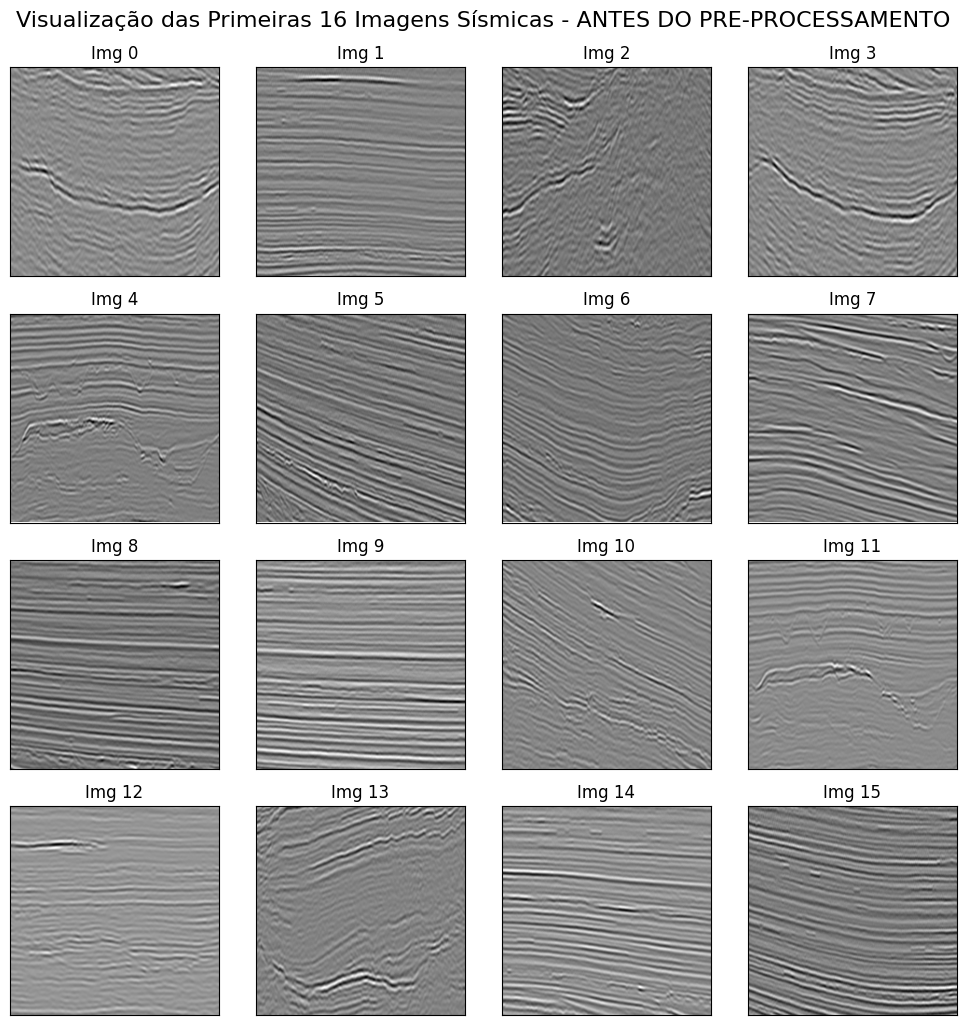

In [16]:

rows = 4
cols = 4
num_plots = rows * cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 10))

# 'axes' é um array 2D de objetos AxesSubplot.
# Precisamos achatá-lo para iterar facilmente sobre ele.
axes = axes.flatten()

# Iterar sobre as primeiras 'num_plots' imagens e plotá-las
for i in range(num_plots):
    # Pega a i-ésima imagem
    image_to_plot = scaled_to_255_arr [i]

    # Plota a imagem no subplot atual
    axes[i].imshow(image_to_plot, cmap='gray')

    # Adiciona um título para cada imagem (opcional)
    axes[i].set_title(f"Img {i}")

    # Remove os "ticks" (marcas) dos eixos para uma visualização mais limpa
    axes[i].set_xticks([])
    axes[i].set_yticks([])

# Ajustar o layout para evitar sobreposição de títulos e eixos
plt.tight_layout()

# Adicionar um título geral para a figura (opcional)
fig.suptitle('Visualização das Primeiras 16 Imagens Sísmicas - ANTES DO PRE-PROCESSAMENTO', fontsize=16, y=1.02)

Text(0.5, 1.02, 'Visualização das Primeiras 16 Imagens Sísmicas - DEPOIS DO PRE-PROCESSAMENTO')

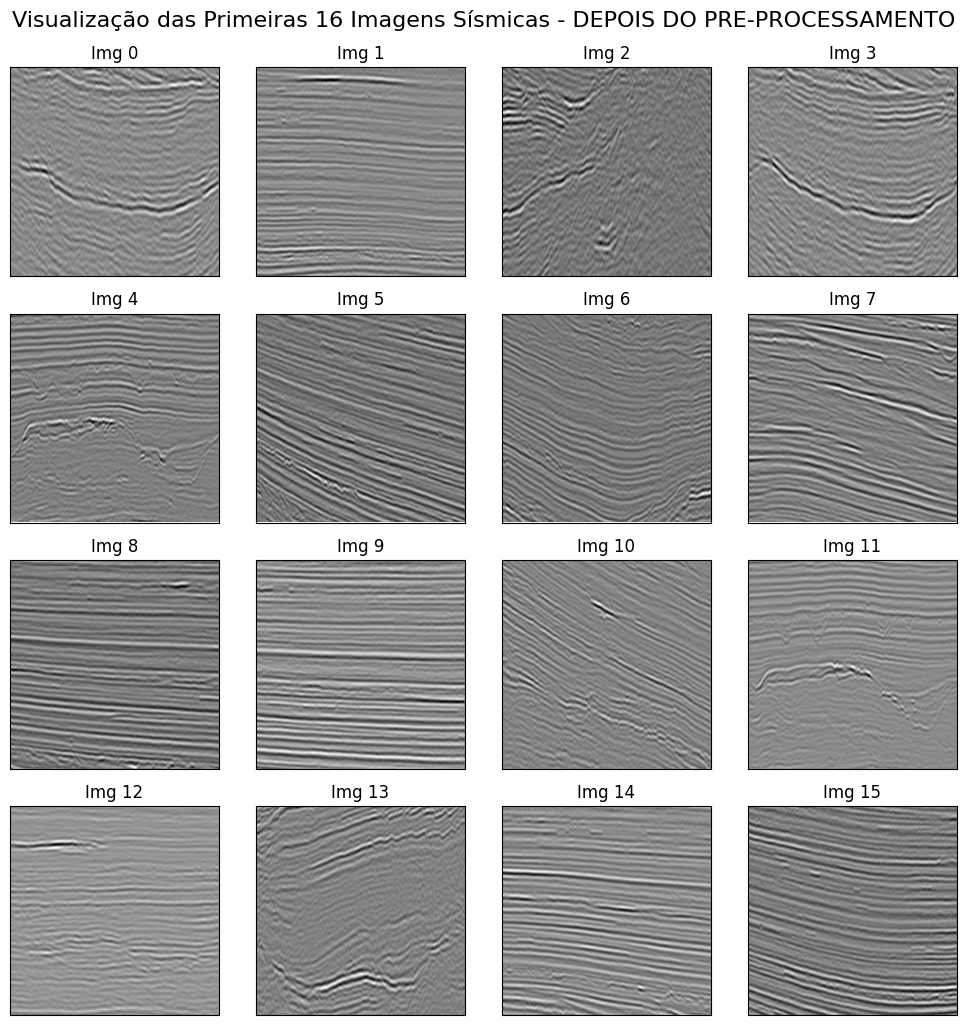

In [17]:

rows = 4
cols = 4
num_plots = rows * cols

fig, axes = plt.subplots(rows, cols, figsize=(10, 10))

# 'axes' é um array 2D de objetos AxesSubplot.
# Precisamos achatá-lo para iterar facilmente sobre ele.
axes = axes.flatten()

# Iterar sobre as primeiras 'num_plots' imagens e plotá-las
for i in range(num_plots):
    # Pega a i-ésima imagem
    image_to_plot = denoised_np [i]

    # Plota a imagem no subplot atual
    axes[i].imshow(image_to_plot, cmap='gray')

    # Adiciona um título para cada imagem (opcional)
    axes[i].set_title(f"Img {i}")

    # Remove os "ticks" (marcas) dos eixos para uma visualização mais limpa
    axes[i].set_xticks([])
    axes[i].set_yticks([])

# Ajustar o layout para evitar sobreposição de títulos e eixos
plt.tight_layout()

# Adicionar um título geral para a figura (opcional)
fig.suptitle('Visualização das Primeiras 16 Imagens Sísmicas - DEPOIS DO PRE-PROCESSAMENTO', fontsize=16, y=1.02)